In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv(r'E:\Rnw\algorithms\Predictive Insight Engine\scaleddata.csv')

In [3]:
df = df.drop("Unnamed: 0", axis=1)
df = df.drop("house_id", axis=1)

In [4]:
df.columns

Index(['area_scaled', 'bedrooms_scaled', 'bathrooms_scaled',
       'location_score_scaled', 'age_years_scaled', 'distance_city_km_scaled',
       'lot_size_sqft_scaled', 'has_garage_scaled', 'has_pool_scaled',
       'renovation_years_ago_scaled', 'house_price_scaled'],
      dtype='object')

In [5]:
X = df[['area_scaled']]  
y = df['house_price_scaled']        

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
slope = model.coef_[0]
intercept = model.intercept_

print("Slope:", slope)
print("Intercept:", intercept)

Slope: 0.624651150442946
Intercept: 0.2294959795043131


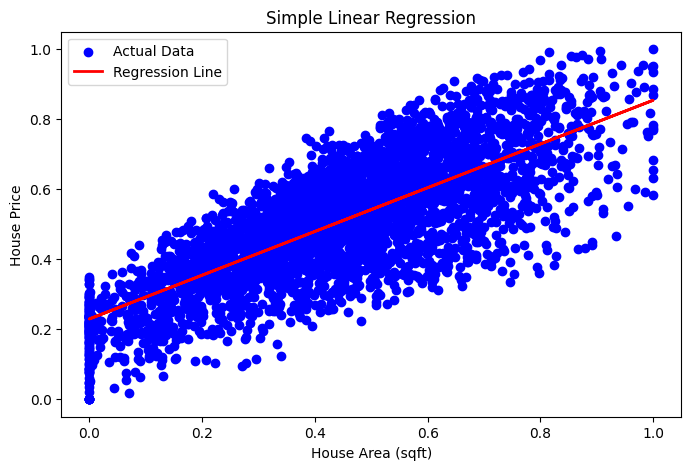

In [9]:
plt.figure(figsize=(8,5))

plt.scatter(X, y, color="blue", label="Actual Data")

plt.plot(X, model.predict(X), color="red", linewidth=2, label="Regression Line")

plt.xlabel("House Area (sqft)")
plt.ylabel("House Price")
plt.title("Simple Linear Regression")

plt.legend()
plt.show()

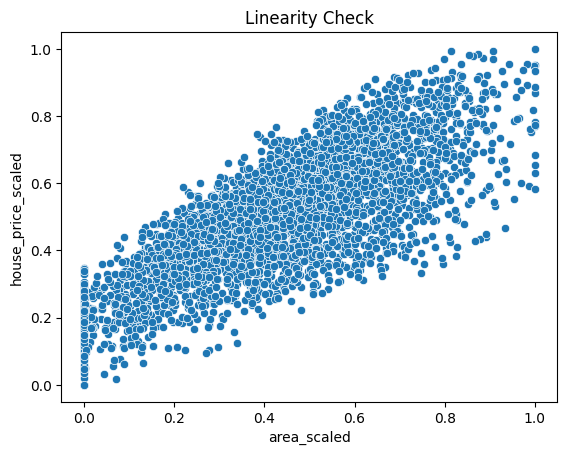

In [12]:
sns.scatterplot(x=df['area_scaled'], y=df['house_price_scaled'])
plt.title("Linearity Check")
plt.show()

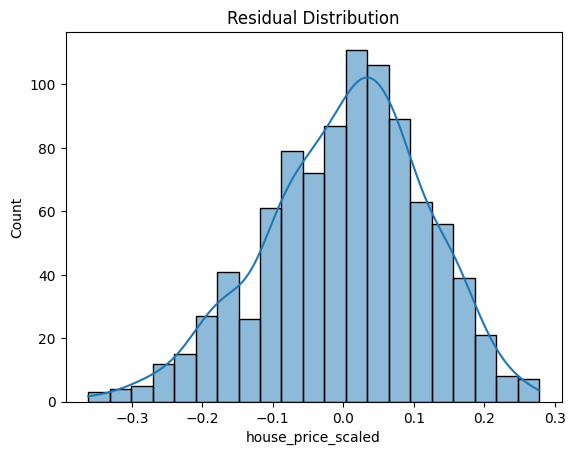

In [13]:
y_pred = model.predict(X_test)

residuals = y_test - y_pred

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

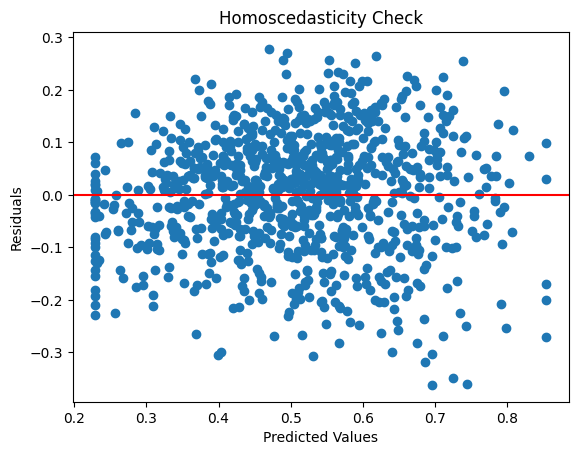

In [14]:
plt.scatter(y_pred, residuals)
plt.axhline(0, color="red")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Homoscedasticity Check")

plt.show()